<a href="https://colab.research.google.com/github/mahima-naik/Youtube_video_transcript_summarizer/blob/main/YYT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers

In [ ]:
!pip install -q youtube_transcript_api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 20.8 MB/s eta 0:00:00


In [ ]:
!pip install -q yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 171.9/171.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.7 MB/s eta 0:00:00


In [ ]:
import re  # Add this line to import the re module
import yt_dlp
from transformers import pipeline
from youtube_transcript_api import YouTubeTranscriptApi, TranscriptsDisabled, NoTranscriptFound

In [ ]:
summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.58k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


In [ ]:
youtube_video ="https://youtu.be/lzILoMjEpaE?si=Tv0ct3zZT_T7pm1q"

In [ ]:
video_id_match = re.search(r"youtu\.be/([a-zA-Z0-9_-]+)", youtube_video)
if video_id_match:
    video_id = video_id_match.group(1)
else:
    print("Error: Invalid YouTube URL")
    video_id = None

In [ ]:
video_id

'lzILoMjEpaE'

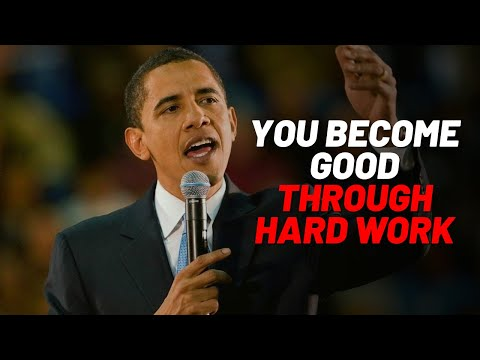

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo(video_id)

In [ ]:
YouTubeTranscriptApi.get_transcript(video_id)
transcript = YouTubeTranscriptApi.get_transcript(video_id)


In [ ]:
transcript[0:5]

[{'text': 'some of the most successful people in',
  'start': 0.799,
  'duration': 3.041},
 {'text': "the world are the ones who've had the",
  'start': 2.24,
  'duration': 3.36},
 {'text': 'most failures', 'start': 3.84, 'duration': 3.28},
 {'text': 'jk rawlings', 'start': 5.6, 'duration': 3.999},
 {'text': 'who wrote harry potter her first harry',
  'start': 7.12,
  'duration': 5.76}]

In [ ]:

if transcript:
    result = " ".join([item['text'] for item in transcript])

    # Adjust chunk sizes dynamically
    max_chunk_size = 1000
    chunks = [result[i:i + max_chunk_size] for i in range(0, len(result), max_chunk_size)]

    summarized_text = []
    for chunk in chunks:
        out = summarizer(chunk, max_length=50, min_length=25, do_sample=False)
        summarized_text.append(out[0]['summary_text'])

    print("Summary:")
    print(" ".join(summarized_text))
else:
    print("No transcript available, skipping summarization.")


Summary:
Some of the most successful people in the world are the ones who've had the most failures. No one's born being good at all things you become good at things through hard work.


In [ ]:
len(str(summarized_text))

178

In [ ]:
str(summarized_text)

'["Some of the most successful people in the world are the ones who\'ve had the most failures. No one\'s born being good at all things you become good at things through hard work."]'